In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.shape

(891, 15)

In [6]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


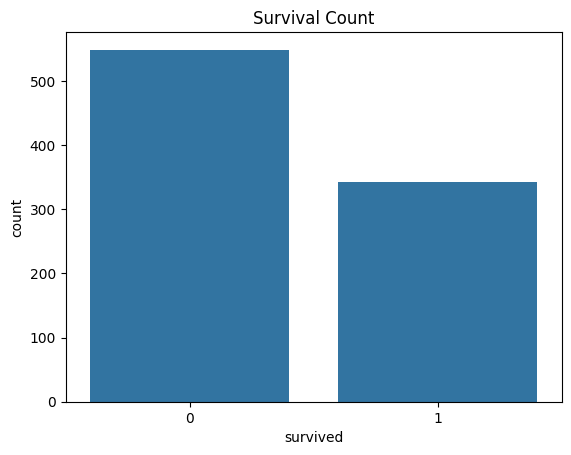

In [8]:
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

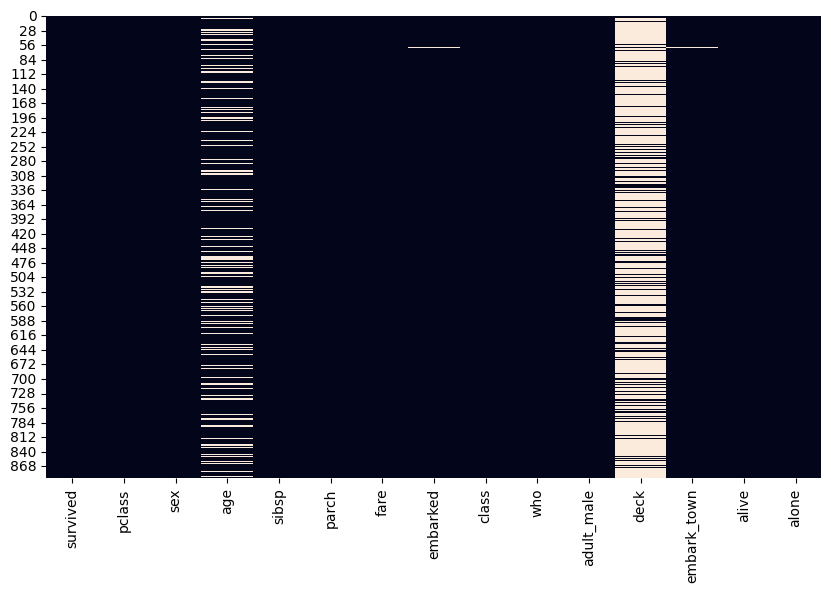

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

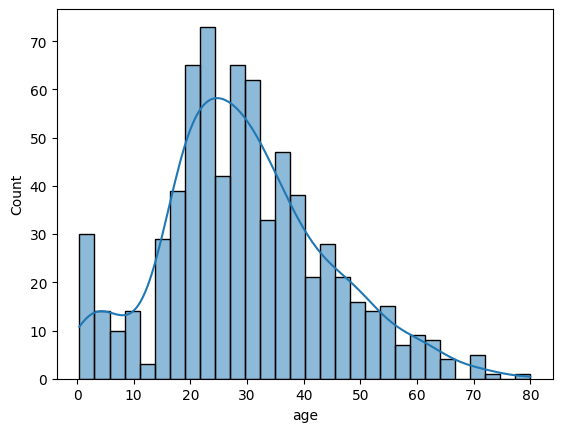

In [10]:
sns.histplot(df['age'], bins=30, kde=True)
plt.show()

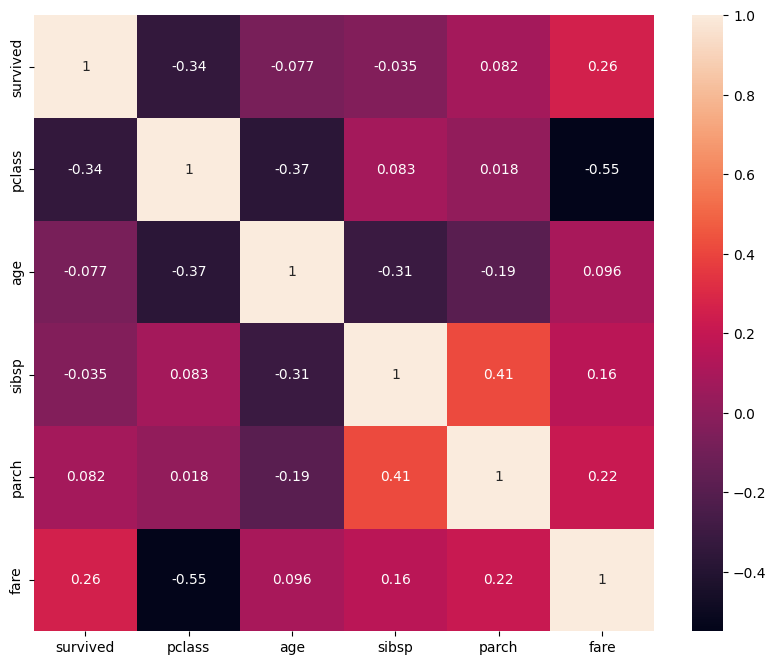

In [11]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [12]:
df = df[['survived',
         'pclass',
         'sex',
         'age',
         'sibsp',
         'parch',
         'fare',
         'embarked']]

In [13]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [14]:
numeric_features = [
    'age',
    'fare',
    'sibsp',
    'parch',
    'pclass'
]

categorical_features = [
    'sex',
    'embarked'
]

In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [19]:
encoded_columns = preprocessor.named_transformers_[
    'cat'
].named_steps['onehot'].get_feature_names_out(categorical_features)

all_columns = numeric_features + list(encoded_columns)

train_df = pd.DataFrame(
    X_train_processed,
    columns=all_columns
)

test_df = pd.DataFrame(
    X_test_processed,
    columns=all_columns
)

In [20]:
train_df.to_csv("processed_titanic_train.csv", index=False)

test_df.to_csv("processed_titanic_test.csv", index=False)

print("Files Saved Successfully")

Files Saved Successfully


In [21]:
train_df.head()

,age,fare,sibsp,parch,pclass,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1.253641,-0.078684,-0.470722,-0.479342,-1.614136,0.0,1.0,0.0,0.0,1.0
1,-0.477284,-0.377145,-0.470722,-0.479342,-0.400551,0.0,1.0,0.0,0.0,1.0
2,0.215086,-0.474867,-0.470722,-0.479342,0.813034,0.0,1.0,0.0,0.0,1.0
3,-0.246494,-0.476230,0.379923,-0.479342,0.813034,0.0,1.0,0.0,0.0,1.0
4,-1.785093,-0.025249,2.931860,2.048742,0.813034,1.0,0.0,0.0,0.0,1.0


In [22]:
train_df.shape

(712, 10)

In [23]:
print(train_df.isnull().sum().sum())

0


In [24]:
print(train_df.head())

        age      fare     sibsp     parch    pclass  sex_female  sex_male  \
0  1.253641 -0.078684 -0.470722 -0.479342 -1.614136         0.0       1.0   
1 -0.477284 -0.377145 -0.470722 -0.479342 -0.400551         0.0       1.0   
2  0.215086 -0.474867 -0.470722 -0.479342  0.813034         0.0       1.0   
3 -0.246494 -0.476230  0.379923 -0.479342  0.813034         0.0       1.0   
4 -1.785093 -0.025249  2.931860  2.048742  0.813034         1.0       0.0   

   embarked_C  embarked_Q  embarked_S  
0         0.0         0.0         1.0  
1         0.0         0.0         1.0  
2         0.0         0.0         1.0  
3         0.0         0.0         1.0  
4         0.0         0.0         1.0  


In [25]:
print(train_df.describe())

                age          fare         sibsp         parch        pclass  \
count  7.120000e+02  7.120000e+02  7.120000e+02  7.120000e+02  7.120000e+02   
mean   1.746418e-17  5.363999e-17  1.746418e-17  2.245395e-17  9.355812e-17   
std    1.000703e+00  1.000703e+00  1.000703e+00  1.000703e+00  1.000703e+00   
min   -2.214363e+00 -6.274674e-01 -4.707224e-01 -4.793416e-01 -1.614136e+00   
25%   -5.542135e-01 -4.748670e-01 -4.707224e-01 -4.793416e-01 -4.005512e-01   
50%   -9.263364e-02 -3.491435e-01 -4.707224e-01 -4.793416e-01  8.130337e-01   
75%    4.458762e-01 -4.017244e-02  3.799232e-01 -4.793416e-01  8.130337e-01   
max    3.907725e+00  9.237724e+00  6.334442e+00  7.104908e+00  8.130337e-01   

       sex_female    sex_male  embarked_C  embarked_Q  embarked_S  
count  712.000000  712.000000  712.000000  712.000000  712.000000  
mean     0.344101    0.655899    0.175562    0.084270    0.740169  
std      0.475408    0.475408    0.380714    0.277987    0.438850  
min      0.00000